# [9665] Homework 1 : NLTK
Data file:
* https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9665/main/data/Womens_clothing_ECommerce_reviews_5k.csv
  * Independent variables
    * Title: String variable for the title of the review
    * Review Text: String variable for the review body
    * Division Name: Categorical name of the product high level division
    * Department Name: Categorical name of the product department name
    * Class Name: Categorical name of the product class name

## Homework Submission Rules (for all Homeworks)
* Homework is due by 6:05 PM on the due date
  * No late submission will be accepted
* Verify that you are submitting the correct homework file in the correct format
* Submit a completed and fully executed Jupyter notebook
  * No other format will be accepted or graded
* Jupyter notebook file naming convention
  * LastName_FirstName_HwY.pdf  [Replace Y with the Homework #]
    * 0.5 points deducted for submitting homework not complying with file naming convention
* Before submission, execute "Kernel -> Restart Kernel and Run All Cells"
  * 0.5 points deducted for not submitting a cleanly executed notebook

## Homework 1 Requirements
* Load data into dataframe
* Perform appropriate text preprocessing & text vectorization
* Generate target variable 'Generated_Sentiment' from the independent variables
* Train SVC model with the objective that >50% of each class is predicted correctly
* Display:
  * model accuracy
  * classification report
  * confusion matrix

In [ ]:
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 02/27/25 22:41:39


### Import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('vader_lexicon')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

### Load data

In [ ]:
# Load data file Womens_clothing_ECommerce_reviews_5k.csv into dataframe
reviews = pd.read_csv('https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9665/main/data/Womens_clothing_ECommerce_reviews_5k.csv')

### Examine data

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
# Display a random sample of 5 rows from dataframe
reviews.sample(5)

,Title,Review Text,Division Name,Department Name,Class Name
3463,Tight in the waist,"These were perfect in the legs, nice and stretchy, but problematic in the waist. i'm generally a 31/size 12, but i had to squeeze to get them to close.\nthey've already gone back. if you have a tinier waist they'd probably be fine.",General,Bottoms,Jeans
2212,Strange fit,"Note the sleeves on the model. that is how your regular size will fit your arms. however, even if you have skinny arms like i do, the sleeves will be tight. i bought my regular size xs and it was clingy with an odd flair and the length seems as though i ordered a petite and i am only 5 ft 2 in.\ni advise to try a few sizes on if you really are interested. the red is truly a red which is a good thing because so often it is hard to find a red that is not neon.",General Petite,Tops,Fine gauge
2739,Beautiful!,"This dress is perfect, length right below the knee, white slip lining adds to quality, smocking fits upper body perfectly.",General,Dresses,Dresses
1407,Great pant for the price,"Buy these, they are a keeper. sturdy fabric, not too thin and they do not sag or stretch after wearing (i tested them before taking the tag off by sitting in them on my couch for several hours). comfy, soft fabric. i will be ordering other colors, hoping that black will be available.",General Petite,Bottoms,Pants
3288,I wanted to love this shirt.,"I order this shirt because it looked like a shirt you could dress up or down. when i got it the shirt was really wrinkled. therefore, i knew it would have to ironed a lot. it was quite boxy and was shorter in the front then in the back. i didn't realize that this shirt was two different fabrics. overall i think this shirt would be more flattering on a woman that was petite.",General,Tops,Knits


### Prepare data - perform necessary text preprocessing

In [ ]:
# checking for null values
reviews.isnull().sum()

,0
Title,0
Review Text,0
Division Name,0
Department Name,0
Class Name,0


In [ ]:
# displaying column names and dtypes
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Title            5000 non-null   object
 1   Review Text      5000 non-null   object
 2   Division Name    5000 non-null   object
 3   Department Name  5000 non-null   object
 4   Class Name       5000 non-null   object
dtypes: object(5)
memory usage: 195.4+ KB


In [ ]:
# creating a new column 'combined'
reviews['combined_text'] = reviews['Title'] + ' ' + reviews['Review Text'] + ' ' + reviews['Division Name'] + ' ' + reviews['Department Name'] + ' ' + reviews['Class Name']

In [ ]:
# ensuring combined_text is created successfully
reviews.head(2)

,Title,Review Text,Division Name,Department Name,Class Name,combined_text
0,Waist gets baggy with wear,"I really liked these jeans initially, but by the end of the day the waist is really baggy. the fabric stretches with wear and takes a wash to get back to its original shape.",General,Bottoms,Jeans,"Waist gets baggy with wear I really liked these jeans initially, but by the end of the day the waist is really baggy. the fabric stretches with wear and takes a wash to get back to its original shape. General Bottoms Jeans"
1,So long!!,"I am of average height, but these pants are so long!! i considered altering them because i like the print, but i don't think it's worth the effort for workout attire so they're going back. shame!!",Initmates,Intimate,Lounge,"So long!! I am of average height, but these pants are so long!! i considered altering them because i like the print, but i don't think it's worth the effort for workout attire so they're going back. shame!! Initmates Intimate Lounge"


In [ ]:
# initialisizng lemmatizer
lemmatizer = WordNetLemmatizer()

# creating stopwords set
stop_words = set(stopwords.words('english'))

In [ ]:
# Function to get the part of speech tag for lemmatization
def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

In [ ]:
# defining a function to clean text
def clean_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    # Convert to lowercase
    tokens = [word.lower() for word in tokens]
    # Remove punctuation and stopwords
    tokens = [word for word in tokens if word.isalnum() and word not in stop_words]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens]
    return ' '.join(tokens)

In [ ]:
# applyiing the function
%%time
reviews['clean_combined_text'] = reviews['combined_text'].apply(clean_text)

CPU times: user 27.7 s, sys: 425 ms, total: 28.2 s
Wall time: 35.8 s


In [ ]:
# Display a random sample of 5 rows from updated dataframe
reviews.sample(5)

,Title,Review Text,Division Name,Department Name,Class Name,combined_text,clean_combined_text
2446,Misrepresented cleaning instructions,I purchased the dusty rose. i thought the picture represented the color accurately. the shirt material had a nice thickness and drape. it felt very luxurious. the opening in the front is cut a little low but workable.\n\nin the end i am disappointed in the care information provided by the site. it listed the garment as machine washable but the care label in the garment states it is dry clean only. i would not have purchased it if i would have know that. i am going to have to return it for this rea,General,Tops,Knits,Misrepresented cleaning instructions I purchased the dusty rose. i thought the picture represented the color accurately. the shirt material had a nice thickness and drape. it felt very luxurious. the opening in the front is cut a little low but workable.\n\nin the end i am disappointed in the care information provided by the site. it listed the garment as machine washable but the care label in the garment states it is dry clean only. i would not have purchased it if i would have know that. i am going to have to return it for this rea General Tops Knits,misrepresent cleaning instruction purchase dusty rise thought picture represent color accurately shirt material nice thickness drape felt luxurious opening front cut little low workable end disappointed care information provide site list garment machine washable care label garment state dry clean would purchase would know go return rea general top knit
3362,"Comfy, runs large","I like the style, but i ordered an extra small (i am5'4' 120#) and it was still too loose fitting on me, had to return, hopefully exchange for xxs",General Petite,Dresses,Dresses,"Comfy, runs large I like the style, but i ordered an extra small (i am5'4' 120#) and it was still too loose fitting on me, had to return, hopefully exchange for xxs General Petite Dresses Dresses",comfy run large like style order extra small am5 4 120 still loose fitting return hopefully exchange xx general petite dress dress
2357,Stylish little sweater,"I fell in love with this on-line and when it arrived today i think i love it even more because the white portion of this sweater is really a medium pink color which looks so chic. although i am not usually into pink, this looks so stylish with the pink instead of the white. this is a piece you might find in a vintage store in the village in nyc. can't wait for it to get chilly so i can wear it. for reference, i am 5'1, 36c chest and the small fit perfect. the quality is really high end as well.",General Petite,Tops,Fine gauge,"Stylish little sweater I fell in love with this on-line and when it arrived today i think i love it even more because the white portion of this sweater is really a medium pink color which looks so chic. although i am not usually into pink, this looks so stylish with the pink instead of the white. this is a piece you might find in a vintage store in the village in nyc. can't wait for it to get chilly so i can wear it. for reference, i am 5'1, 36c chest and the small fit perfect. the quality is really high end as well. General Petite Tops Fine gauge",stylish little sweater fell love arrive today think love even white portion sweater really medium pink color look chic although usually pink look stylish pink instead white piece might find vintage store village nyc ca wait get chilly wear reference 5 1 36c chest small fit perfect quality really high end well general petite top fine gauge
3202,"Cute, but...","Wanted to love this dress, bit it wasn't to be. strange fit, and doesn't drape nicely, as in the photo. also, the blue color was much darker in person. wouldn't recommend.",General,Dresses,Dresses,"Cute, but... Wanted to love this dress, bit it wasn't to be. strange fit, and doesn't drape nicely, as in the photo. also, the blue color was much darker in person. wouldn't recommend. General Dresses Dresses",cute wa

### Generate sentiment from data

In [ ]:
# initiating Sentiment Intensity Analyzer
sia = SentimentIntensityAnalyzer()

In [ ]:
# getting the lexicon
vader_lexicon = sia.lexicon
len(vader_lexicon)

7502

In [ ]:
# generating sentiment scores for cleaned text
reviews['sentiment_score'] = reviews['clean_combined_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

In [ ]:
# categorizing sentiment as Positive, Neutral, or Negative
reviews['sentiment_label'] = reviews['sentiment_score'].apply(lambda x: 'positive' if x > 0.05 else 'negative' if x < -0.05 else 'neutral')

# displaying results
reviews[['clean_combined_text', 'sentiment_score', 'sentiment_label']].head()

,clean_combined_text,sentiment_score,sentiment_label
0,waist get baggy wear really like jean initially end day waist really baggy fabric stretch wear take wash get back original shape general bottom jean,0.6240,positive
1,long average height pant long consider alter like print think worth effort workout attire go back shame initmates intimate lounge,0.0772,positive
2,slip small dress pretty disappointed slip small like previous customer inch taller model feel comfortable tunic legging nice nice enough keep return general dress dress,0.8885,positive
3,look good thought would try reviewer love comfort zone look like poncho baggy tank underneath worth price tassel look bit worn well general top knit,0.9287,positive
4,dress love look dress length feel little awkward might height 5 4 think alter sure return love color back cut may well length taller individual general petite dress dress,0.8858,positive


In [ ]:
# displaying class distribution
reviews['sentiment_label'].value_counts()

,count
sentiment_label,
positive,4631
negative,313
neutral,56


In [ ]:
# label encoding the dependent variable since it is categorical
le = LabelEncoder()
y_encoded = le.fit_transform(reviews['sentiment_label'])

### Vectorize data

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
text_tfidf_counts= tfidf.fit_transform(reviews['clean_combined_text']).toarray()
text_tfidf_counts.shape

(5000, 5000)

### Split data into training and test sets

In [ ]:
# TF-IDF
X_train_tfidf, X_test_tfidf, y_train_encoded, y_test_encoded = train_test_split(
    text_tfidf_counts, y_encoded, stratify=y_encoded, test_size=0.25, random_state=42)

### Train SVC model with default hyperparameters

In [ ]:
# initialising svc model
svc_model = SVC(random_state=42)

# training the model
svc_model.fit(X_train_tfidf, y_train_encoded)

# making predictions
y_pred = svc_model.predict(X_test_tfidf)

### Evaluate SVC model with default hyperparameters

In [ ]:
# Display accuracy
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9264


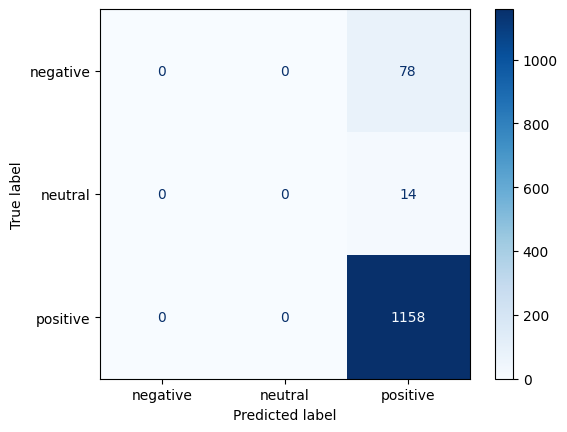

In [ ]:
# computing the confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.show()

### Re-train SVC model with the objective that >50% of the predictions for each class is predicted correctly
- Update hyperparameters appropriately to achieve the stated objective


In [ ]:
# using smote to balance classes
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train_encoded)

In [ ]:
# checking class distribution after smote
Counter(y_train_smote)

Counter({2: 3473, 0: 3473, 1: 3473})

In [ ]:
# initiating randomised search to find the best hyperparameter combinations
# from sklearn.model_selection import RandomizedSearchCV
# import numpy as np

# param_dist = {
  #  'C': np.logspace(-2, 2, 10),
  # 'kernel': ['linear', 'rbf', 'poly'],
  # 'gamma': ['scale', 'auto'],
  # 'degree': [2, 3, 4],  # only used for poly kernel
  # 'class_weight': [None, 'balanced']
#}

# performing the search
# random_search = RandomizedSearchCV(svc_model, param_distributions=param_dist,
                               #    n_iter=20, cv=5, scoring='recall_macro', n_jobs=-1, random_state=42)
# random_search.fit(X_train_tfidf, y_train_encoded)

# printing the best hyperparameters
# print("Best Hyperparameters:", random_search.best_params_)

The best hyperparameters suggested by RandomSearch were: Best Hyperparameters: {'kernel': 'linear', 'gamma': 'scale', 'degree': 2, 'class_weight': 'balanced', 'C': 0.21544346900318834}

In [ ]:
# tuning the hyperparameters
svc_model_smote = SVC(C=0.21544346900318834, kernel='linear', gamma='scale', degree=2, class_weight= 'balanced', random_state=42)

In [ ]:
# retraining the model
svc_model_smote.fit(X_train_smote, y_train_smote)

# making predictions
y_pred_smote = svc_model_smote.predict(X_test_tfidf)

### Evaluate updated SVC model

In [ ]:
# Display accuracy
accuracy_smote = accuracy_score(y_test_encoded, y_pred_smote)
print(f'Accuracy: {accuracy_smote:.4f}')

Accuracy: 0.9208


In [ ]:
# classification report
print(classification_report(y_test_encoded, y_pred_smote))

              precision    recall  f1-score   support

           0       0.45      0.62      0.52        78
           1       0.00      0.00      0.00        14
           2       0.97      0.95      0.96      1158

    accuracy                           0.92      1250
   macro avg       0.47      0.52      0.49      1250
weighted avg       0.92      0.92      0.92      1250



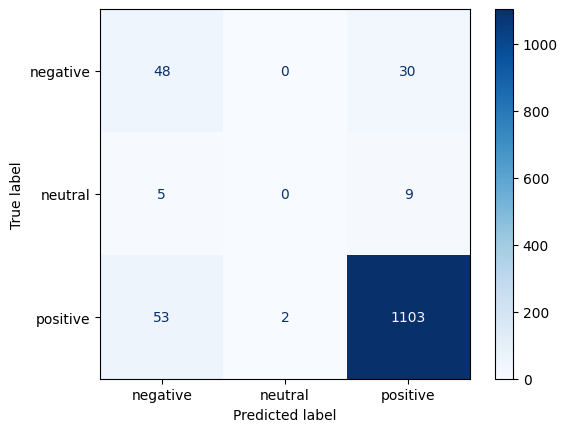

In [ ]:
# Display the confusion matrix
cm_smote = confusion_matrix(y_test_encoded, y_pred_smote)
disp_smote = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=le.classes_)
disp_smote.plot(cmap='Blues')